<a href="https://colab.research.google.com/github/themehmi/Life-Expectancy-Predictor/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Linear Regression**

What is Linear Regression?


At its simplest, linear regression is a method used to predict the value of one variable based on the value of another. It assumes there is a straight-line relationship between your input (independent variable) and your output (dependent variable).

The Math Behind ItIn a simple linear regression, the relationship is expressed by the equation for a straight line:
             
             y = mx + c(for simple linear regression)


*   y: The variable you are trying to predict (e.g., Price).
*   x: The variable you are using to make the prediction (e.g., Miles).
*   m: The slope, which tells you how much $y$ changes for every unit of $x$.
*   c: The y-intercept, which is the value of $y$ when $x$ is zero (like a base starting fee).





**MLR- Multiple Linear Regression**

In Multiple Linear Regression, we assume the relationship between the dependent variable $y$ and $k$ independent variables $x_1, x_2, ... x_k$ is linear.

The mathematical model is expressed as:
$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_kx_k + \epsilon$$

Breaking Down the Components

* $y$: The dependent (target) variable.
* $x_1, x_2, ... x_k$: The independent variables (features).
* $\beta_0$: The y-intercept (the value of $y$ when all $x$ variables are zero).* $\beta_1, \beta_2, ... \beta_k$: The regression coefficients. Each represents the change in $y$ for a one-unit change in that specific $x$, assuming all other variables stay constant.
* $\epsilon$: The error term (or residual). This accounts for the variation in $y$ that the model cannot explain.


**What sets the value of $\beta$ ??**

The value of $\beta$ isn't arbitrary; it is "set" by the data itself through a process of optimization or when put in train model. The goal is to find the specific values for each $\beta$ that make the model's predictions as close to the actual observed data as possible.

# **Example with a dataset**

In [ ]:
#import a dataset
import pandas as pd
from pandas import read_csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
path=("https://raw.githubusercontent.com/themehmi/datasets/refs/heads/main/Life%20Expectancy%20Data.csv")
df=pd.read_csv(path)
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
print(df.info)

<bound method DataFrame.info of           Country  Year      Status  Life expectancy   Adult Mortality  \
0     Afghanistan  2015  Developing              65.0            263.0   
1     Afghanistan  2014  Developing              59.9            271.0   
2     Afghanistan  2013  Developing              59.9            268.0   
3     Afghanistan  2012  Developing              59.5            272.0   
4     Afghanistan  2011  Developing              59.2            275.0   
...           ...   ...         ...               ...              ...   
2933     Zimbabwe  2004  Developing              44.3            723.0   
2934     Zimbabwe  2003  Developing              44.5            715.0   
2935     Zimbabwe  2002  Developing              44.8             73.0   
2936     Zimbabwe  2001  Developing              45.3            686.0   
2937     Zimbabwe  2000  Developing              46.0            665.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \


Data Preprocessing

In [ ]:
# The dataset often has trailing spaces (e.g., "Life expectancy ")
df.columns = df.columns.str.strip()

# Preprocess Data
# Drop non-numeric identifiers for the regression model
df_model = df.drop(['Country', 'Year'], axis=1)

# Convert 'Status' (Developed/Developing) into numbers (0 and 1)
df_model = pd.get_dummies(df_model, columns=['Status'], drop_first=True)

# Handle Missing Values: For this example, we drop rows with any NaN values
df_model = df_model.dropna()

In [ ]:
#Define Features (X) and Target (y)
X = df_model.drop('Life expectancy', axis=1)
y = df_model['Life expectancy']

# Split Data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Create Prediction
y_pred = model.predict(X_test)

# Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

# Print Results
print(f"Model Intercept: {model.intercept_:.4f}")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Model Intercept: 54.4669
R-squared Score: 0.8105
Mean Squared Error: 13.4579
Root Mean Squared Error: 3.6685


In [ ]:
# View Coefficients (The Beta values)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Beta Coefficient'])
print("\nVariable Coefficients:")
print(coefficients.sort_values(by='Beta Coefficient', ascending=False))


Variable Coefficients:
                                 Beta Coefficient
Income composition of resources      8.882302e+00
Schooling                            9.492528e-01
infant deaths                        9.665366e-02
Total expenditure                    9.170593e-02
BMI                                  2.727912e-02
Diphtheria                           1.485295e-02
Polio                                9.390542e-03
percentage expenditure               4.025681e-04
Population                           7.227318e-10
GDP                                 -2.585353e-06
Measles                             -6.931207e-06
Hepatitis B                         -8.838715e-03
Adult Mortality                     -1.651039e-02
thinness 5-9 years                  -4.420882e-02
thinness  1-19 years                -4.555423e-02
under-five deaths                   -7.302571e-02
Alcohol                             -1.131651e-01
HIV/AIDS                            -4.314752e-01
Status_Developing         

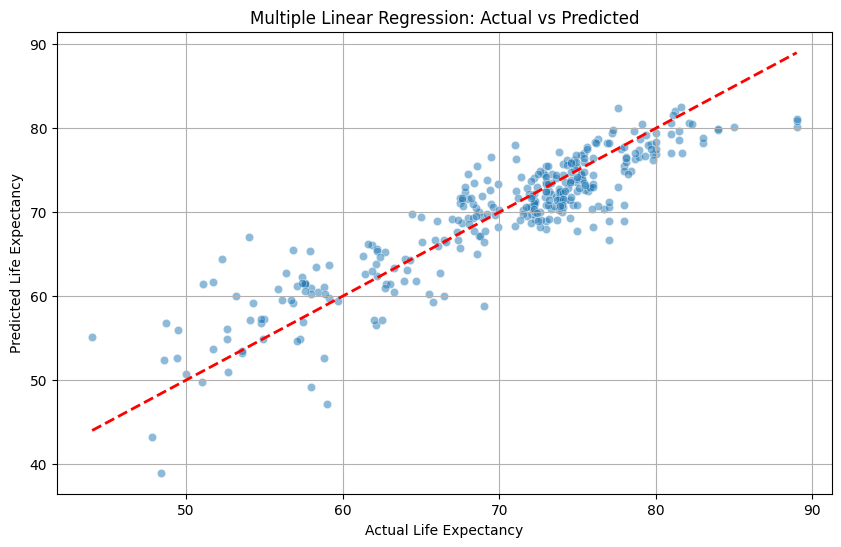

In [ ]:
# Visualize Predicted vs Actual
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.grid(True)
plt.show()

In [ ]:

# Create a results DataFrame using the test set's index
results_df = X_test.copy()

# Add the actual values
results_df['Actual_Life_Expectancy'] = y_test

# Add the predicted values
results_df['Predicted_Life_Expectancy'] = y_pred

# Calculate the error (Residuals) for each row
results_df['Error'] = results_df['Actual_Life_Expectancy'] - results_df['Predicted_Life_Expectancy']

print(results_df[['Actual_Life_Expectancy', 'Predicted_Life_Expectancy', 'Error']])

      Actual_Life_Expectancy  Predicted_Life_Expectancy     Error
1210                    67.5                  71.734162 -4.234162
2273                    73.8                  72.731704  1.068296
1005                    79.1                  80.496348 -1.396348
2926                    54.9                  54.884527  0.015473
518                     48.6                  52.368852 -3.768852
...                      ...                        ...       ...
1453                    71.0                  78.067074 -7.067074
2821                    75.4                  76.467231 -1.067231
483                     55.9                  60.899281 -4.999281
290                     69.1                  67.737772  1.362228
486                     54.8                  57.334498 -2.534498

[330 rows x 3 columns]


In [ ]:
# save model using joblib
import joblib
joblib.dump(model, 'model.joblib')


['model.joblib']

In [ ]:
# load saved model

loaded_model = joblib.load('model.joblib')